<a href="https://colab.research.google.com/github/kuroshkarimi/Machine-Learning-and-Data-Analysis/blob/main/Deep_Learning/Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project overview
The objective of this project is to develop, train and evaluate deep-learning models that classify grayscale images of fashion products into ten categories.
The project uses the Fashion-MNIST dataset, which contains \(28 * 28\)-pixel grayscale images of clothing and footwear.


This project will compare two deep-learning approaches:
1. A fully connected multilayer perceptron, or MLP
2. A convolutional neural network, or CNN


### Business-style problem definition
Imagine an online clothing retailer that receives large numbers of product images. Each image must be assigned to a product category before it can be displayed, searched or recommended to customers.
Manually assigning these categories would be:
- Slow
- Expensive
- Inconsistent
- Difficult to scale
The machine-learning task is therefore to create an automated image-classification system that predicts the correct product category from a grayscale image.


### Machine-learning problem
This is a supervised multiclass image-classification problem.
For every image, the model predicts one of ten possible classes from 0 to 9.

### Dataset
- Fashion-MNIST contains 70,000 grayscale images.
- Dataset portion	Number of images
- Original training set	60,000
- Original test set	10,000
- Image size	(28 * 28)
- Number of classes	10


Each pixel has an intensity value between 0 and 255.

Class definitions

Label	Product category
- 0	T-shirt/top
- 1	Trouser
- 2	Pullover
- 3	Dress
- 4	Coat
- 5	Sandal
- 6	Shirt
- 7	Sneaker
- 8	Bag
- 9	Ankle boot


The dataset can be loaded directly through Keras:
from tensorflow.keras.datasets import fashion_mnist

(X_train_full, y_train_full), (X_test, y_test) = (
    fashion_mnist.load_data()
)

#Main project objective
The main objective is to build a deep-learning model that accurately classifies Fashion-MNIST images while maintaining good performance on previously unseen data.

The project should answer the following questions:
1. Can a neural network classify the ten fashion categories reliably?
2. How does an MLP compare with a CNN?
3. Which product categories are most difficult to distinguish?
7. How confident is the model when it makes incorrect predictions?

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout, BatchNormalization
from keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.layers import Conv2D, MaxPooling2D, SpatialDropout2D, Flatten

In [29]:
(X_TRAIN, y_train), (X_TEST, y_test) = fashion_mnist.load_data()

In [30]:
print(X_TRAIN.shape)
print(y_train.shape)
print(X_TEST.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [31]:
# Flattening of the data

X_TRAIN_FLAT = X_TRAIN.reshape(X_TRAIN.shape[0], -1)
X_TEST_FLAT = X_TEST.reshape(X_TEST.shape[0], -1)
print(X_TRAIN_FLAT.shape, X_TEST_FLAT.shape)

(60000, 784) (10000, 784)


In [32]:
# Splitting the training section into train and validation
'''
X_train = X_TRAIN_FLAT[:-10000]
X_val = X_TRAIN_FLAT[-10000:]

y_train = y_train[:-10000]
y_val = y_train[-10000:]

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)'''


X_train1, X_val1, y_train1, y_val1 = train_test_split(X_TRAIN_FLAT, y_train, test_size = 0.2, random_state = 42)
print(X_train1.shape, X_val1.shape)
print(y_train1.shape, y_val1.shape)


(48000, 784) (12000, 784)
(48000,) (12000,)


In [33]:
X_train1 = (X_train1 - np.min(X_train1, axis = 1, keepdims = True)) / (np.max(X_train1, axis = 1, keepdims = True) - np.min(X_train1, axis = 1, keepdims = True))

X_val1 = (X_val1 - np.min(X_val1, axis = 1, keepdims = True)) / (np.max(X_val1, axis = 1, keepdims = True) - np.min(X_val1, axis = 1, keepdims = True))

In [9]:

model1 = Sequential([
    Input (shape = (X_train1.shape[1], ), name = 'input'),

    Dense (128, activation = 'relu', kernel_initializer= 'he_normal'),
    #BatchNormalization(),
    Dropout(0.3),

    Dense (64, activation = 'relu', kernel_initializer= 'he_normal'),
    #BatchNormalization(),
    Dropout(0.3),

    Dense (32, activation = 'relu', kernel_initializer= 'he_normal'),
    #BatchNormalization(),
    Dropout(0.3),
    Dense (10, activation = 'softmax', kernel_initializer = 'glorot_normal', name = 'output')
])

In [10]:
model1.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [11]:
ES1 = EarlyStopping(
    monitor = 'val_loss',
    mode = 'min',
    patience = 8,
    restore_best_weights = True
)

MC1 = ModelCheckpoint(
    'best_model1.keras',
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True
)

LR1 = ReduceLROnPlateau(
    monitor = 'val_loss',
    mode = 'min',
    patience = 5,
    factor = 0.5
)



In [12]:
HISTORY1 = model1.fit(X_train1, y_train1,
          validation_data = (X_val1, y_val1),
          epochs = 100,
          batch_size = 128,
          callbacks = [ES1, MC1, LR1],
          verbose = 1
          )

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.6389 - loss: 1.0225 - val_accuracy: 0.8111 - val_loss: 0.5184 - learning_rate: 0.0010
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.7868 - loss: 0.6186 - val_accuracy: 0.8471 - val_loss: 0.4412 - learning_rate: 0.0010
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8177 - loss: 0.5366 - val_accuracy: 0.8526 - val_loss: 0.4132 - learning_rate: 0.0010
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.8308 - loss: 0.4958 - val_accuracy: 0.8627 - val_loss: 0.3842 - learning_rate: 0.0010
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8417 - loss: 0.4654 - val_accuracy: 0.8608 - val_loss: 0.3885 - learning_rate: 0.0010
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8468 - loss: 0.4494 - val_accuracy: 0.8611 - val_loss: 0.3887 - learning_rate: 0.0010
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8532 -

In [ ]:

plt.plot(HISTORY1.history['loss'])
plt.plot(HISTORY1.history['val_loss'])
plt.grid()

In [14]:
# we can also see the combined effects of the weight gradients at each layers
# along with the batch normalization gama and beta coefficients


loss_function = (
    tf.keras.losses.SparseCategoricalCrossentropy()
)

x_batch = tf.convert_to_tensor(
    X_train1[1000:1000+128],
    dtype = tf.float32
)

y_batch = tf.convert_to_tensor(
    y_train1[1000:1000+128],
    dtype = tf.float32
)

with tf.GradientTape() as tape:

  predictions = model1(
      x_batch,
      training = True

  )

  loss = loss_function(
      y_batch,
      predictions
  )

  gradients = tape.gradient(
      loss,
      model1.trainable_variables
  )


for variable, gradient in zip(
    model1.trainable_variables,
    gradients
):

    if gradient is not None:

        gradient_norm = tf.norm(
            gradient
        ).numpy()

        print(
            variable.name,
            gradient_norm
        )

kernel 0.61049104
bias 0.04758428
kernel 0.16246174
bias 0.054168265
kernel 0.10910785
bias 0.041052204
kernel 0.31362867
bias 0.04404162


In [16]:

(X_TRAIN, y_train), (X_TEST, y_test) = fashion_mnist.load_data()

x_train2, x_val2, y_train2, y_val2 = train_test_split(X_TRAIN, y_train, test_size = 0.2, random_state = 42)


In [17]:
# Normalizing the data

x_train2 = (x_train2 - np.min(x_train2, axis = (1, 2), keepdims = True)) / (np.max(x_train2, axis = (1, 2), keepdims = True) -
                                                                    np.min(x_train2, axis = (1, 2), keepdims = True))

x_val2 = (x_val2 - np.min(x_val2, axis = (1, 2), keepdims = True)) / (np.max(x_val2, axis = (1, 2), keepdims = True) -
                                                                np.min(x_val2, axis = (1, 2), keepdims = True))


x_test2 = (X_TEST - np.min(X_TEST, axis = (1, 2), keepdims = True)) / (np.max(X_TEST, axis = (1, 2), keepdims = True) -
                                                                  np.min(X_TEST, axis = (1, 2), keepdims = True))

In [18]:

model2 = Sequential([
    Input (shape = (x_train2.shape[1], x_train2.shape[2], 1)),

    Conv2D(32, (3, 3), activation = 'relu', kernel_initializer = 'he_normal'),
    MaxPooling2D((2, 2)),
    SpatialDropout2D(0.3),

    Conv2D(64, (3, 3), activation = 'relu', kernel_initializer = 'he_normal'),
    MaxPooling2D((2, 2)),
    SpatialDropout2D(0.3),

    Flatten(),
    Dense(10, activation = 'softmax')
])

In [19]:
model2.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [20]:
ES2 = EarlyStopping(
    monitor = 'val_loss',
    mode = 'min',
    patience = 8,
    restore_best_weights = True
)

MC2 = ModelCheckpoint(
    'best_model2.keras',
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True
)

LR2 = ReduceLROnPlateau(
    monitor = 'val_loss',
    mode = 'min',
    patience = 5,
    factor = 0.5
)



In [21]:
HISTORY2 = model2.fit(
    x_train2, y_train2,
    validation_data = (x_val2, y_val2),
    epochs = 100,
    batch_size = 128,
    callbacks = [ES2, MC2, LR2],
    verbose = 1
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 113ms/step - accuracy: 0.7581 - loss: 0.6702 - val_accuracy: 0.8530 - val_loss: 0.4116 - learning_rate: 0.0010
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 112ms/step - accuracy: 0.8441 - loss: 0.4382 - val_accuracy: 0.8648 - val_loss: 0.3703 - learning_rate: 0.0010
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 45s 120ms/step - accuracy: 0.8608 - loss: 0.3912 - val_accuracy: 0.8756 - val_loss: 0.3411 - learning_rate: 0.0010
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 108ms/step - accuracy: 0.8712 - loss: 0.3626 - val_accuracy: 0.8796 - val_loss: 0.3257 - learning_rate: 0.0010
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 47s 125ms/step - accuracy: 0.8758 - loss: 0.3454 - val_accuracy: 0.8892 - val_loss: 0.3106 - learning_rate: 0.0010
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 44s 116ms/step - accuracy: 0.8820 - loss: 0.3314 - val_accuracy: 0.8891 - val_loss: 0.2995 - learning_rate: 0.0010
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 111ms/step - accura

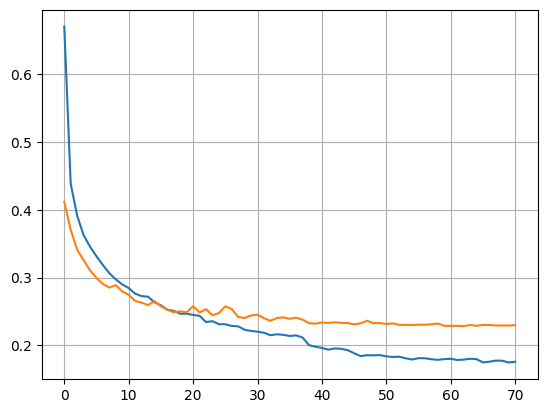

In [23]:
plt.plot(HISTORY2.history['loss'])
plt.plot(HISTORY2.history['val_loss'])
plt.grid()